In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from pathlib import Path
import re
import seaborn as sns

In [84]:
data_root_path = Path('/astrum/home/hpchzy/code/data/20260608/')

# 使用 (?P<date>\d+) 定义命名分组
date_base = re.search(r'/data/(?P<date_base>\d+)/?', str(data_root_path)).groupdict()['date_base']
date_base

'20260608'

{'hostname': 'cgnr6760pn2', 'date_stamp': '20260608-150447', 'kernel': 'jacobi2d5p', 'timer': 'wtime', 'np': '64', 'size': '64'}
(39680,)


   rank   ns  step     hostname       date_stamp      kernel  timer  np  size
0    54  114     0  cgnr6760pn2  20260608-150447  jacobi2d5p  wtime  64    64
1    54   96     1  cgnr6760pn2  20260608-150447  jacobi2d5p  wtime  64    64
2    54   96     2  cgnr6760pn2  20260608-150447  jacobi2d5p  wtime  64    64
3    54   95     3  cgnr6760pn2  20260608-150447  jacobi2d5p  wtime  64    64
4    54   95     4  cgnr6760pn2  20260608-150447  jacobi2d5p  wtime  64    64
               df        sum_sq      mean_sq         F        PR(>F)
C(step)     619.0  8.420782e+05  1360.384761  1.455341  1.393426e-12
C(rank)      63.0  2.091274e+05  3319.482738  3.551187  8.833131e-20
Residual  38997.0  3.645256e+07   934.752975       NaN           NaN


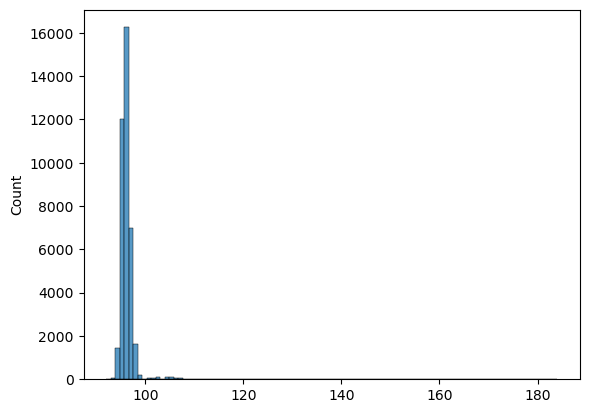

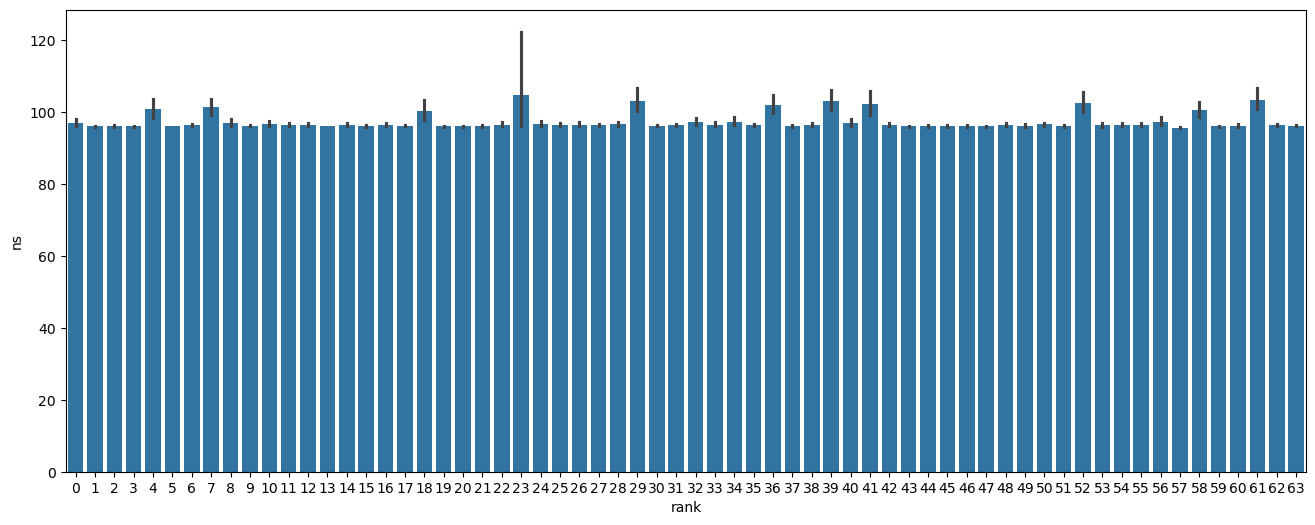

In [ ]:

for p in data_root_path.rglob(rf'*size*/'):
    if not re.search(r"size\d+$", p.name):
        continue
    m = re.search(rf'data/{date_base}/(?P<hostname>.*?)/output_filt/(?P<date_stamp>.*?)/(?P<kernel>.*?)_(?P<timer>.*?)_np(?P<np>\d+?)_size(?P<size>\d+)', str(p)).groupdict()
    print(m)

    all_cores_df_list = []
    for csv_file in p.glob("*.csv"):
        rank = re.search(rf'time_(?P<rank>\d+?)_{m["hostname"]}', csv_file.name).groupdict()['rank']
        rank = int(rank)

        # print(csv_file.name)
        df = pd.read_csv(csv_file, header=None, names=['rank', 'ns'])
        df['step'] = df.index
        df['hostname'] = m['hostname']
        df['date_stamp'] = m['date_stamp']
        df['kernel'] = m['kernel']
        df['timer'] = m['timer']
        df['np'] = int(m['np'])
        df['size'] = int(m['size'])

        all_cores_df_list.append(df)

    all_cores_df = pd.concat(all_cores_df_list, ignore_index=True)
    ns_np = all_cores_df['ns'].to_numpy()
    
    print(ns_np.shape)

    q995 = np.quantile(ns_np, 0.995)
    ns_plot = ns_np[ns_np <= q995]
    
    plt.figure(figsize=(16, 6))
    sns.histplot(ns_plot, bins=100, kde=False)
    plt.show()

    all_cores_df = all_cores_df.astype({'rank': 'int32', 'step': 'int32', 'ns': 'int32'})
    print(all_cores_df.head())

    # 回归检验
    import statsmodels.api as sm
    # X = sm.add_constant(all_cores_df['rank'])
    # model = sm.OLS(all_cores_df['ns'], X).fit()
    # print(model.summary()) # 查看斜率系数是否显著，即 ns 是否随 step 变化

    # 方差分析
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm
    # 建立模型：ns 受 step 和 rank 共同影响
    model = ols('ns ~ C(step) + C(rank)', data=all_cores_df).fit()
    anova_results = anova_lm(model)
    print(anova_results)

    plt.figure(figsize=(16, 6))
    sns.barplot(data=all_cores_df, x='rank', y='ns')
    plt.show()
    break



In [ ]:
for p in data_root_path.rglob('*/tr_hist.csv'):
    print(p.parent)
    print(os.listdir(p.parent))
    m = re.search(rf'data/{date_base}/(?P<hostname>.*?)/output_filt/(?P<date_stamp>.*?)/(?P<kernel>.*?)_(?P<timer>.*?)_np(?P<np>\d+?)_size(?P<size>\d+?)', str(p)).groupdict()
    # m = re.search(f'data/{date_base}/(?P<hostname>.*?)/output_fit/(?P<date_stamp>.*?)/(?P<kernel>.*?)_(?P<timer>.*?)_np(?P<np>\d+?)_size(?P<size>\d+?)[(_filt)|tr]?', str(p)).groupdict() # ERROR
    print(m)
    

/astrum/home/hpchzy/code/data/20260608/cgnr6760pn2/output_filt/20260608-150447/jacobi2d5p_tsc_np64_size64_filt
['tr_hist.csv', 'tf.csv', 'wd.out', 'tm_hist.csv', 'er.out', 'sim_cdf.csv', 'met.csv', 'ep.out']
{'hostname': 'cgnr6760pn2', 'date_stamp': '20260608-150447', 'kernel': 'jacobi2d5p', 'timer': 'tsc', 'np': '64', 'size': '6'}
/astrum/home/hpchzy/code/data/20260608/cgnr6760pn2/output_filt/20260608-150447/jacobi2d5p_papix6_np64_size64_filt
['ep.out', 'sim_cdf.csv', 'met.csv', 'er.out', 'tr_hist.csv', 'wd.out', 'tf.csv', 'tm_hist.csv']
{'hostname': 'cgnr6760pn2', 'date_stamp': '20260608-150447', 'kernel': 'jacobi2d5p', 'timer': 'papix6', 'np': '64', 'size': '6'}
/astrum/home/hpchzy/code/data/20260608/cgnr6760pn2/output_filt/20260608-150447/jacobi2d5p_tsc_native_np64_size64_filt
['er.out', 'tr_hist.csv', 'tf.csv', 'tm_hist.csv', 'wd.out', 'ep.out', 'sim_cdf.csv', 'met.csv']
{'hostname': 'cgnr6760pn2', 'date_stamp': '20260608-150447', 'kernel': 'jacobi2d5p', 'timer': 'tsc_native', 'np